# Preprocessing & Pelabelan Data

## Setup & Load

In [1]:
!pip install pandas numpy nltk Sastrawi scikit-learn matplotlib seaborn wordcloud tqdm -q

In [2]:
import pandas as pd
import re, os
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.preprocessing import LabelEncoder

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
os.makedirs('data', exist_ok=True)
print("Import selesai")

Import selesai


In [3]:
df = pd.read_csv('data/raw_reviews.csv')
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10831 entries, 0 to 10830
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   app_name   10831 non-null  object
 1   app_id     10831 non-null  object
 2   review_id  10831 non-null  object
 3   username   10831 non-null  object
 4   content    10831 non-null  object
 5   score      10831 non-null  int64 
 6   thumbs_up  10831 non-null  int64 
 7   date       10831 non-null  object
dtypes: int64(2), object(6)
memory usage: 677.1+ KB
None


,app_name,app_id,review_id,username,content,score,thumbs_up,date
0,Tokopedia,com.tokopedia.tkpd,c3402469-db7d-452b-8c6c-09336cf5ab9f,edelweis land,"kebanyak iklan anjir , mengganggu",1,0,2026-05-27 07:31:11
1,Tokopedia,com.tokopedia.tkpd,d77a4155-1a8b-4f3e-beb8-768173c41410,Tuwaga Pat,ati2bagi pengguna baru.apk scam.brg batal otom...,1,0,2026-05-27 07:30:40
2,Tokopedia,com.tokopedia.tkpd,bb889c2d-9d7c-4b2d-8300-67076fe0d1d0,M.Saiful Muzil,bagus sekali,5,0,2026-05-27 07:10:17
3,Tokopedia,com.tokopedia.tkpd,9d4c053b-b5a7-4923-8db8-333fba3b9f60,Ovalia Sugito,"Harga barang tertera 77rb, kq setelah mau di b...",1,0,2026-05-27 05:32:44
4,Tokopedia,com.tokopedia.tkpd,ebbfba4d-7e92-4bc8-b4b8-56b6211b63e4,Mulday Mulyadi,membantu belanja,5,0,2026-05-27 00:57:20


## Labeling

In [4]:
def label_sentiment(score):
    if score <= 2:
        return 'Negatif'
    elif score == 3:
        return 'Netral'
    else:
        return 'Positif'

df['sentiment'] = df['score'].apply(label_sentiment)
print("Distribusi Label Sentimen:")
counts = df['sentiment'].value_counts()
print(counts)
print(f"\nRasio Negatif : Netral : Positif = "
      f"{counts.get('Negatif',0)} : {counts.get('Netral',0)} : {counts.get('Positif',0)}")

Distribusi Label Sentimen:
sentiment
Positif    5190
Negatif    5121
Netral      520
Name: count, dtype: int64

Rasio Negatif : Netral : Positif = 5121 : 520 : 5190


## preprocessing

In [5]:
factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer() 
factory_sw = StopWordRemoverFactory()
stop_word_remover = factory_sw.create_stop_word_remover()

# Stopwords
EXTRA_STOPWORDS = {
    'yg','yang','dgn','dengan','di','ke','nya','aja',
    'gak','ga','udah','udh','lg','lagi','tp','tapi',
    'klo','kalau','klu','kak','min','bang','mas','mba',
    'bgt','banget','deh','sih','nih','loh','dong',
    'jg','juga','sdh','sudah','blm','belum','gt','gitu'
}

def clean_text(text):
    if pd.isna(text) or text.strip() == '':
        return ''
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[@#]\w+', ' ', text)
    text = re.sub(r'[\U00010000-\U0010ffff]', ' ', text, flags=re.UNICODE)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = stop_word_remover.remove(text)
    tokens = [w for w in text.split() if w not in EXTRA_STOPWORDS and len(w) > 2]
    text = ' '.join(tokens)
    text = stemmer.stem(text)
    return text

In [6]:
from tqdm import tqdm
tqdm.pandas()

print("Memproses teks")
df['cleaned_text'] = df['content'].progress_apply(clean_text)

# Hapus hasil kosong setelah preprocessing
df_clean = df[df['cleaned_text'].str.strip().str.len() > 3].copy()
df_clean = df_clean.reset_index(drop=True)

print(f"\nData setelah preprocessing: {len(df_clean):,} baris")
print(f"Data terhapus: {len(df) - len(df_clean):,} baris")
print(f"\nContoh hasil preprocessing:")
for i in [0, 10, 50]:
    print(f"\n[{df_clean['sentiment'].iloc[i]}]")
    print(f"Asli    : {df_clean['content'].iloc[i][:80]}...")
    print(f"Bersih  : {df_clean['cleaned_text'].iloc[i][:80]}...")

Memproses teks


100%|██████████| 10831/10831 [21:38<00:00,  8.34it/s] 


Data setelah preprocessing: 10,769 baris
Data terhapus: 62 baris

Contoh hasil preprocessing:

[Negatif]
Asli    : kebanyak iklan anjir , mengganggu...
Bersih  : banyak iklan anjir ganggu...

[Negatif]
Asli    : gak habis pikir sama Tokopedia. pas mau kembalikan barag tertera geratis . pas k...
Bersih  : habis pikir sama tokopedia pas mau kembali barag tera gerat pas kurir ambil bara...

[Positif]
Asli    : sangat membantu dalam transaksi dan selalu memberikan kemudahan dalam pembayaran...
Bersih  : sangat bantu transaksi selalu beri mudah bayar terimakasih tokopedia...


## Atasi Kelas Imbalance

In [11]:
from sklearn.utils import resample

print("Distribusi SEBELUM balancing:")
print(df_clean['sentiment'].value_counts())
print(f"Total: {len(df_clean):,}")
TARGET_PER_CLASS = 5000

def smart_balance(df, target):
    results = []
    for cls in ['Negatif', 'Netral', 'Positif']:
        df_cls = df[df['sentiment'] == cls]
        n = len(df_cls)
        if n >= target:
            df_sampled = resample(df_cls, n_samples=target,
                                  random_state=42, replace=False)
            print(f"  {cls:<8}: {n:,} -> {target:,} undersample")
        else:
            df_sampled = resample(df_cls, n_samples=target,
                                  random_state=42, replace=True)
            print(f"  {cls:<8}: {n:,} -> {target:,} oversample")
        results.append(df_sampled)

    df_balanced = pd.concat(results)
    return df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nTarget per kelas: {TARGET_PER_CLASS:,}")
df_balanced = smart_balance(df_clean, TARGET_PER_CLASS)

print(f"\nDistribusi SETELAH balancing:")
print(df_balanced['sentiment'].value_counts())
print(f"\nTotal data final: {len(df_balanced):,}")

Distribusi SEBELUM balancing:
sentiment
Positif    5142
Negatif    5109
Netral      518
Name: count, dtype: int64
Total: 10,769

Target per kelas: 5,000
  Negatif : 5,109 -> 5,000 undersample
  Netral  : 518 -> 5,000 oversample
  Positif : 5,142 -> 5,000 undersample

Distribusi SETELAH balancing:
sentiment
Positif    5000
Netral     5000
Negatif    5000
Name: count, dtype: int64

Total data final: 15,000


## Encoding

In [12]:
label_map = {'Negatif': 0, 'Netral': 1, 'Positif': 2}
df_balanced['label'] = df_balanced['sentiment'].map(label_map)

le = LabelEncoder()
le.fit(['Negatif', 'Netral', 'Positif'])

print("Label mapping:")
for k, v in label_map.items():
    print(f"  {k} -> {v}")

Label mapping:
  Negatif -> 0
  Netral -> 1
  Positif -> 2


## Save

In [13]:
cols_save = ['content', 'cleaned_text', 'score', 'sentiment', 'label', 'app_name']
df_final = df_balanced[cols_save].copy()
df_final.to_csv('data/processed_data3.csv', index=False, encoding='utf-8-sig')

print(f"Dataset tersimpan: data/processed_data3.csv")
print(f"Total: {len(df_final):,} sampel")
print(f"Kolom: {list(df_final.columns)}")
print(f"\nStatistik dataset:")
print(df_final['sentiment'].value_counts())

Dataset tersimpan: data/processed_data3.csv
Total: 15,000 sampel
Kolom: ['content', 'cleaned_text', 'score', 'sentiment', 'label', 'app_name']

Statistik dataset:
sentiment
Positif    5000
Netral     5000
Negatif    5000
Name: count, dtype: int64


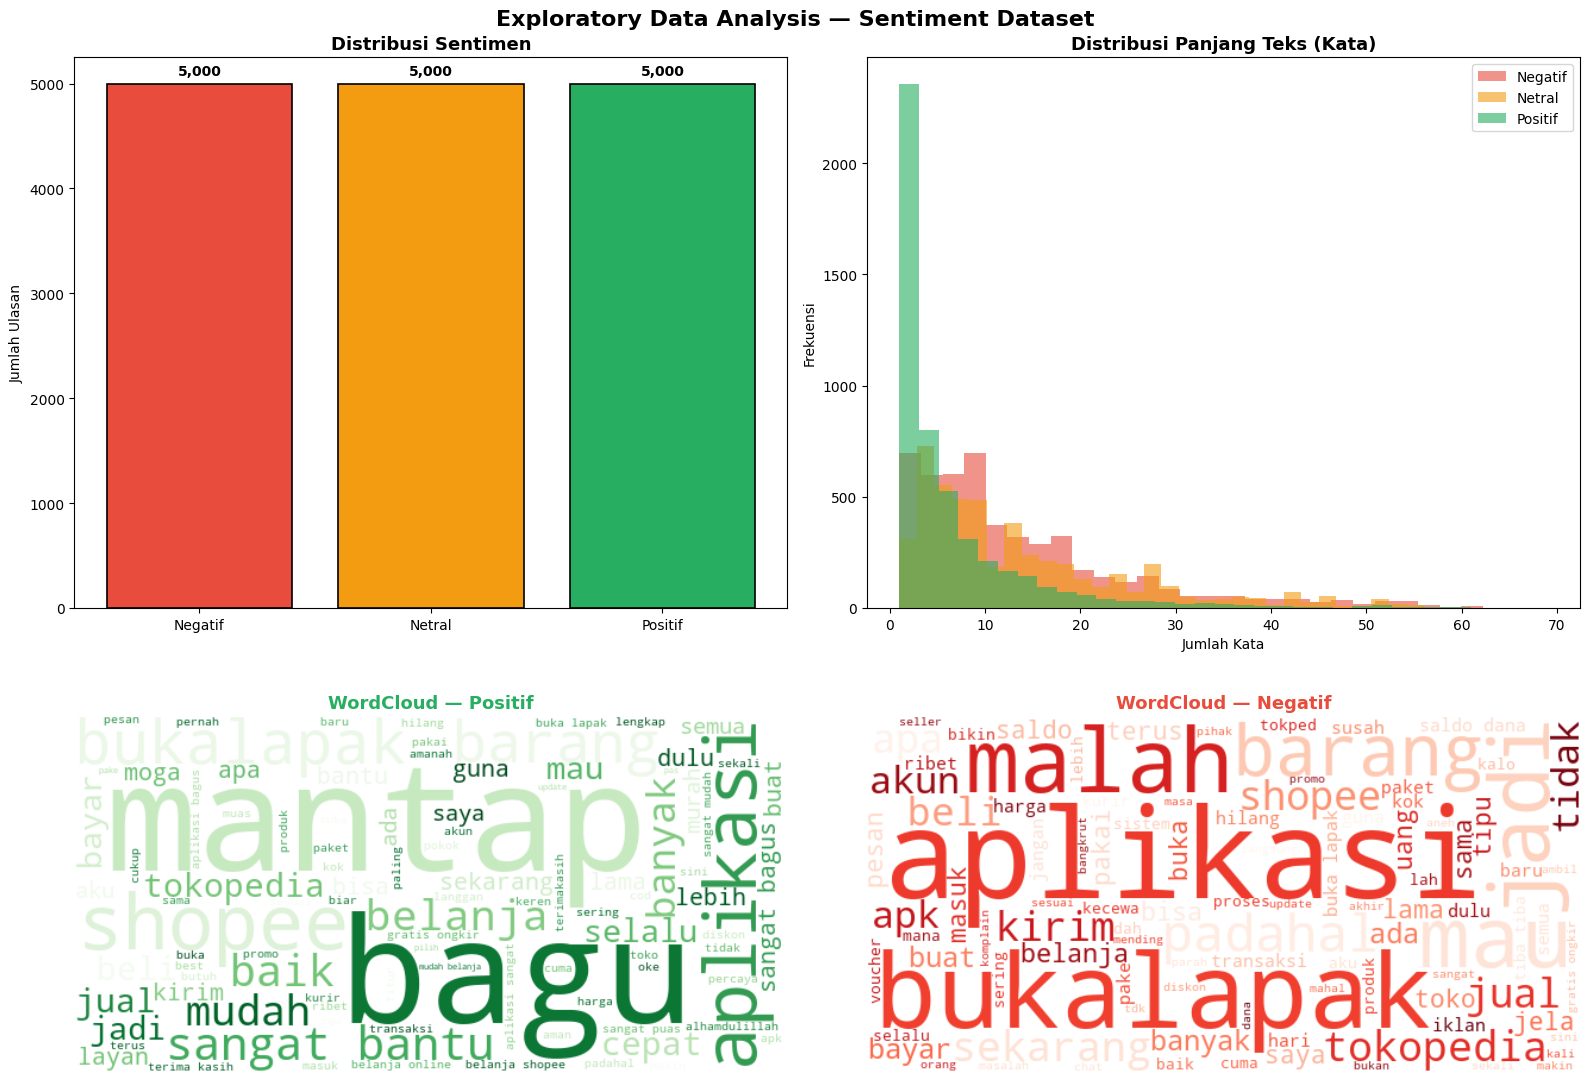

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Exploratory Data Analysis — Sentiment Dataset', fontsize=16, fontweight='bold')

colors = {'Negatif':'#e74c3c', 'Netral':'#f39c12', 'Positif':'#27ae60'}
color_list = [colors[c] for c in ['Negatif', 'Netral', 'Positif']]

counts = df_final['sentiment'].value_counts()[['Negatif', 'Netral', 'Positif']]
bars = axes[0,0].bar(counts.index, counts.values, color=color_list, edgecolor='black', linewidth=1.2)
axes[0,0].set_title('Distribusi Sentimen', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Jumlah Ulasan')
for bar, count in zip(bars, counts.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                   f'{count:,}', ha='center', va='bottom', fontweight='bold')

df_final['text_len'] = df_final['cleaned_text'].str.split().str.len()
for sentiment, color in colors.items():
    data = df_final[df_final['sentiment'] == sentiment]['text_len']
    axes[0,1].hist(data, bins=30, alpha=0.6, label=sentiment, color=color)
axes[0,1].set_title('Distribusi Panjang Teks (Kata)', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Jumlah Kata')
axes[0,1].set_ylabel('Frekuensi')
axes[0,1].legend()

text_pos = ' '.join(df_final[df_final['sentiment'] == 'Positif']['cleaned_text'])
wc_pos = WordCloud(width=600, height=300, background_color='white',
                   colormap='Greens', max_words=100).generate(text_pos)
axes[1,0].imshow(wc_pos, interpolation='bilinear')
axes[1,0].axis('off')
axes[1,0].set_title('WordCloud — Positif', fontsize=13, fontweight='bold', color='#27ae60')

text_neg = ' '.join(df_final[df_final['sentiment'] == 'Negatif']['cleaned_text'])
wc_neg = WordCloud(width=600, height=300, background_color='white',
                   colormap='Reds', max_words=100).generate(text_neg)
axes[1,1].imshow(wc_neg, interpolation='bilinear')
axes[1,1].axis('off')
axes[1,1].set_title('WordCloud — Negatif', fontsize=13, fontweight='bold', color='#e74c3c')

plt.tight_layout()
plt.show()